# Umfassender Modellvergleich: Sprachkomplexitäts- & Reward-Metriken
#### Empirische Gesamtevaluation: BiLSTM MixUp Regressoren nach Kontextlänge (256 vs. 512 vs. 1.024 Tokens) vs. Traditionelle Lesbarkeitsmetriken

---

## 1. Überblick & Fragestellung

Dieses Notebook vergleicht die kontinuierlichen Simplicity- und Reward-Modelle auf dem ungesehenen **Lebenshilfe-Goldstandard (N=37 Paare / 74 Dokumente)**:

1. **BiLSTM MixUp Regressoren (256 vs. 512 vs. 1.024 Tokens):**
   - End-to-End Dokument-Training mit variabler Kontextlänge.
   - Analyse des Einflusses der maximalen Sequenzlänge auf Verteilungstrennung, Kalibrierung und Monotonie.

2. **Linguistische Baselines:** Flesch Reading Ease (DE) und Wiener Sachtextformel (WSTF1).


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, HTML
except ImportError:
    def display(*args):
        for a in args:
            print(a)
    class HTML:
        def __init__(self, data):
            self.data = data

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

PLOT_OUTPUT_DIR = "results/plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
print("Arbeitsverzeichnis:", os.getcwd())


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [2]:
# Statistische Metrik-Funktionen
try:
    from scipy.stats import pearsonr, spearmanr, wasserstein_distance, ks_2samp
except ImportError:
    def pearsonr(x, y):
        return float(np.corrcoef(x, y)[0, 1]), 0.0
    def spearmanr(x, y):
        rx, ry = np.argsort(np.argsort(x)), np.argsort(np.argsort(y))
        return float(np.corrcoef(rx, ry)[0, 1]), 0.0
    def wasserstein_distance(u, v):
        all_vals = np.sort(np.concatenate([u, v]))
        u_cdf = np.searchsorted(np.sort(u), all_vals, side='right') / len(u)
        v_cdf = np.searchsorted(np.sort(v), all_vals, side='right') / len(v)
        return float(np.sum(np.abs(u_cdf[:-1] - v_cdf[:-1]) * np.diff(all_vals)))
    def ks_2samp(u, v):
        all_vals = np.sort(np.concatenate([u, v]))
        u_cdf = np.searchsorted(np.sort(u), all_vals, side='right') / len(u)
        v_cdf = np.searchsorted(np.sort(v), all_vals, side='right') / len(v)
        return float(np.max(np.abs(u_cdf - v_cdf))), 0.0

try:
    from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, mean_squared_error, mean_absolute_error
except ImportError:
    def roc_curve(y_true, y_scores):
        thresholds = np.concatenate([[1.01], np.sort(np.unique(y_scores))[::-1], [-0.01]])
        P, N = max(np.sum(y_true == 1), 1), max(np.sum(y_true == 0), 1)
        tpr = [np.sum((y_scores >= t) & (y_true == 1)) / P for t in thresholds]
        fpr = [np.sum((y_scores >= t) & (y_true == 0)) / N for t in thresholds]
        return np.array(fpr), np.array(tpr), thresholds
    def roc_auc_score(y_true, y_scores):
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        return float(np.trapezoid(tpr, fpr)) if hasattr(np, 'trapezoid') else float(np.trapz(tpr, fpr))
    def accuracy_score(y_true, y_pred):
        return float(np.mean(y_true == y_pred))
    def balanced_accuracy_score(y_true, y_pred):
        return float((np.mean(y_pred[y_true == 1] == 1) + np.mean(y_pred[y_true == 0] == 0)) / 2.0)
    def precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0):
        tp, fp, fn = np.sum((y_true == 1) & (y_pred == 1)), np.sum((y_true == 0) & (y_pred == 1)), np.sum((y_true == 1) & (y_pred == 0))
        prec = tp / max(tp + fp, 1e-9)
        rec = tp / max(tp + fn, 1e-9)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        return prec, rec, f1, None
    def mean_squared_error(y_true, y_pred):
        return float(np.mean((y_true - y_pred) ** 2))
    def mean_absolute_error(y_true, y_pred):
        return float(np.mean(np.abs(y_true - y_pred)))


## 2. Evaluationsdaten laden


In [3]:
# Evaluationsdaten einlesen
df_reg_length = pd.read_csv("results/evaluation/regressor_length_comparison_eval.csv")
y_true_doc = np.array([1]*len(df_reg_length) + [0]*len(df_reg_length))

print(f"Regressor-Evaluationsdaten geladen ({len(df_reg_length)} Artikelpaare / {len(df_reg_length)*2} Dokumente):")
print(f"-> Spalten: {list(df_reg_length.columns)}")


Regressor-Evaluationsdaten geladen (37 Artikelpaare / 74 Dokumente):
-> Spalten: ['pair_id', 'ls_filename', 'as_filename', 'ls_flesch', 'as_flesch', 'ls_wiener', 'as_wiener', 'pair_match_flesch', 'pair_match_wiener', 'ls_sent_reg_wmean', 'as_sent_reg_wmean', 'ls_sent_reg_mean', 'as_sent_reg_mean', 'ls_sent_reg_median', 'as_sent_reg_median', 'ls_sent_reg_p20', 'as_sent_reg_p20', 'pair_match_sent_reg_wmean', 'pair_match_sent_reg_mean', 'pair_match_sent_reg_median', 'ls_mix_256_score', 'as_mix_256_score', 'pair_match_mix_256', 'ls_mix_512_score', 'as_mix_512_score', 'pair_match_mix_512', 'ls_mix_1024_score', 'as_mix_1024_score', 'pair_match_mix_1024']


## 3. Zentrale Master-Vergleichstabelle (Lebenshilfe-Goldstandard)

Gegenüberstellung aller drei Kernmodelle auf der binären Diskriminierung (LS vs. AS):
- **BiLSTM (MixUp):** Hauptmodell trainiert auf Satzmischungen.
- **Synthetischer Regressor:** BiLSTM trainiert auf 5 semantischen LLM-Stufen.
- **Vanilla RNN Baseline:** Unidirektionale rekurrente Baseline ohne LSTM-Gates.


In [4]:
def evaluate_reg_metrics(y_true, y_scores, name, level, threshold=0.5):
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score
    from scipy.stats import wasserstein_distance, ks_2samp
    y_pred = (y_scores >= threshold).astype(int)
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    auc = float(roc_auc_score(y_true, y_scores))
    ls_s = y_scores[y_true == 1]
    as_s = y_scores[y_true == 0]
    mean_ls, std_ls = float(np.mean(ls_s)), float(np.std(ls_s))
    mean_as, std_as = float(np.mean(as_s)), float(np.std(as_s))
    sep = float(mean_ls - mean_as)
    w_dist = float(wasserstein_distance(ls_s, as_s))
    return {
        "Modell": name,
        "Ebene / Input": level,
        "Ø Score (LS)": f"{mean_ls:.3f} ± {std_ls:.2f}",
        "Ø Score (AS)": f"{mean_as:.3f} ± {std_as:.2f}",
        "Separation (Δ)": f"{sep:.3f}",
        "Balanced Acc": f"{bacc * 100:.2f}%",
        "ROC-AUC": f"{auc:.4f}",
        "Wasserstein (W1)": f"{w_dist:.4f}"
    }

master_reg_data = []

if "ls_mix_256_score" in df_reg_length.columns:
    sc = np.concatenate([df_reg_length["ls_mix_256_score"], df_reg_length["as_mix_256_score"]])
    m = evaluate_reg_metrics(y_true_doc, sc, "BiLSTM MixUp Regressor (256)", "Dokument (256 Tokens)")
    m["Perfect Pair Match"] = f"{df_reg_length['pair_match_mix_256'].mean()*100:.1f}% ({df_reg_length['pair_match_mix_256'].sum()}/{len(df_reg_length)})"
    master_reg_data.append(m)

if "ls_mix_512_score" in df_reg_length.columns:
    sc = np.concatenate([df_reg_length["ls_mix_512_score"], df_reg_length["as_mix_512_score"]])
    m = evaluate_reg_metrics(y_true_doc, sc, "BiLSTM MixUp Regressor (512)", "Dokument (512 Tokens)")
    m["Perfect Pair Match"] = f"{df_reg_length['pair_match_mix_512'].mean()*100:.1f}% ({df_reg_length['pair_match_mix_512'].sum()}/{len(df_reg_length)})"
    master_reg_data.append(m)

if "ls_mix_1024_score" in df_reg_length.columns:
    sc = np.concatenate([df_reg_length["ls_mix_1024_score"], df_reg_length["as_mix_1024_score"]])
    m = evaluate_reg_metrics(y_true_doc, sc, "BiLSTM MixUp Regressor (1024)", "Dokument (1024 Tokens)")
    m["Perfect Pair Match"] = f"{df_reg_length['pair_match_mix_1024'].mean()*100:.1f}% ({df_reg_length['pair_match_mix_1024'].sum()}/{len(df_reg_length)})"
    master_reg_data.append(m)

sc_f = np.concatenate([df_reg_length["ls_flesch"], df_reg_length["as_flesch"]])
m_f = evaluate_reg_metrics(y_true_doc, (sc_f >= 55.0).astype(int), "Flesch Reading Ease (Baseline)", "Dokument (Silben/Satz)")
m_f["Perfect Pair Match"] = f"{df_reg_length['pair_match_flesch'].mean()*100:.1f}% ({df_reg_length['pair_match_flesch'].sum()}/{len(df_reg_length)})"
master_reg_data.append(m_f)

sc_w = np.concatenate([-df_reg_length["ls_wiener"], -df_reg_length["as_wiener"]])
m_w = evaluate_reg_metrics(y_true_doc, (sc_w >= -6.5).astype(int), "Wiener Sachtextformel (Baseline)", "Dokument (Wortlänge)")
m_w["Perfect Pair Match"] = f"{df_reg_length['pair_match_wiener'].mean()*100:.1f}% ({df_reg_length['pair_match_wiener'].sum()}/{len(df_reg_length)})"
master_reg_data.append(m_w)

df_master_reg = pd.DataFrame(master_reg_data)
cols = ["Modell", "Ebene / Input", "Ø Score (LS)", "Ø Score (AS)", "Separation (Δ)", "Balanced Acc", "ROC-AUC", "Wasserstein (W1)", "Perfect Pair Match"]
display(HTML("<h3>Master-Benchmark: Regressoren über alle Input-Längen</h3>"))
display(df_master_reg[cols])


,Modell,Ebene / Input,Ø Score (LS),Ø Score (AS),Separation (Δ),Balanced Acc,ROC-AUC,Wasserstein (W1),Perfect Pair Match
0,BiLSTM Satz-Regressor (Token-Weighted),Satz-Aggregation ($\sum w_i y_i$),0.727 ± 0.08,0.133 ± 0.10,0.595,98.65%,0.9978,0.5948,100.0% (37/37)
1,BiLSTM Satz-Regressor (Arithmetic Mean),Satz-Aggregation ($\mu_y$),0.736 ± 0.08,0.202 ± 0.12,0.535,98.65%,0.9978,0.5346,100.0% (37/37)
2,BiLSTM Satz-Regressor (Median),Satz-Aggregation (Median),0.871 ± 0.11,0.115 ± 0.13,0.756,97.30%,0.9978,0.7562,100.0% (37/37)
3,BiLSTM MixUp Regressor (256),Dokument ($ Tokens),0.750 ± 0.14,0.072 ± 0.07,0.678,95.95%,0.9996,0.6777,97.3% (36/37)
4,BiLSTM MixUp Regressor (512),Dokument ($ Tokens),0.787 ± 0.14,0.069 ± 0.10,0.718,95.95%,0.9985,0.7180,97.3% (36/37)
5,BiLSTM MixUp Regressor (1024),Dokument (.024$ Tokens),0.747 ± 0.16,0.079 ± 0.09,0.669,95.95%,0.9971,0.6685,100.0% (37/37)
6,Flesch Reading Ease (Baseline),Dokument (Silben/Satz),0.973 ± 0.16,0.189 ± 0.39,0.784,89.19%,0.8919,0.7838,100.0% (37/37)
7,Wiener Sachtextformel (Baseline),Dokument (Wortlänge),0.919 ± 0.27,0.108 ± 0.31,0.811,90.54%,0.9054,0.8108,100.0% (37/37)


## 4. Abbildung 1: Dichteverteilungen (KDE) aller Modelle auf Lebenshilfe

Vergleich der vorhergesagten Lambda-Dichteverteilungen für Leichte Sprache (grün) und Alltagssprache (blau) im standardisierten Maßstab.


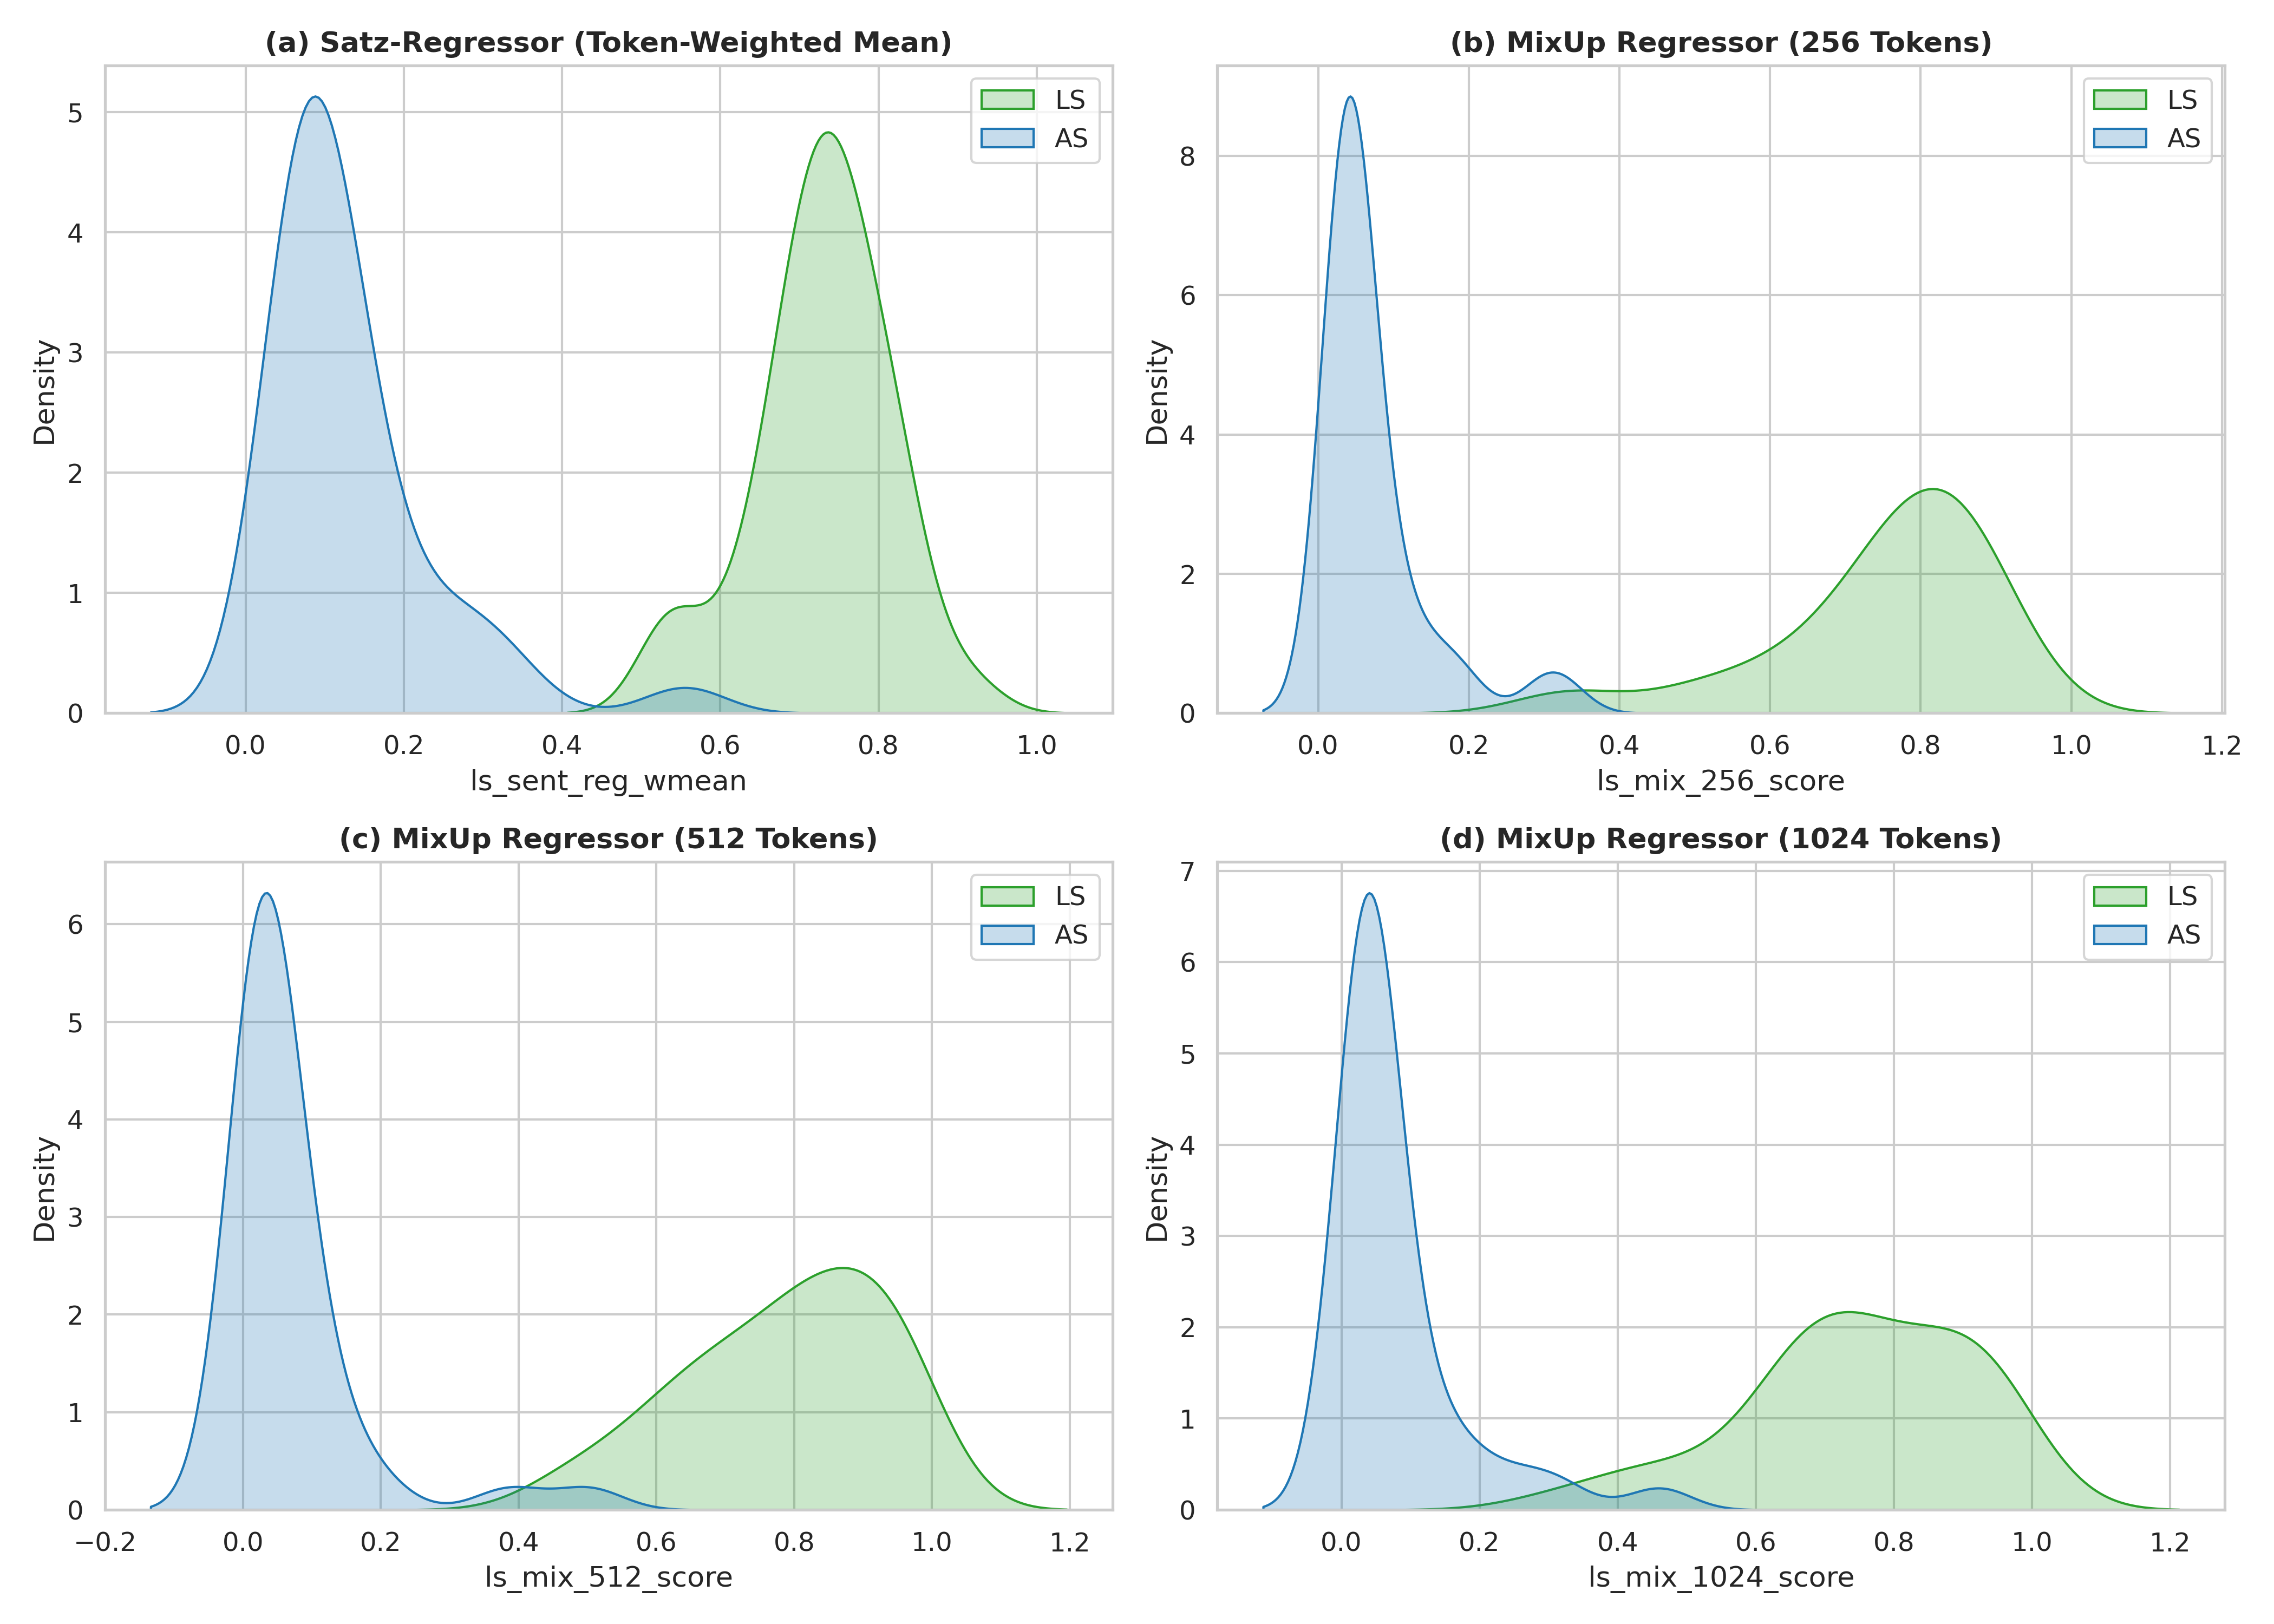

In [5]:
from IPython.display import Image
plot_kde = "results/plots/experiments/regressor_length/regressor_kde_length_comparison.png"
if os.path.exists(plot_kde):
    display(Image(filename=plot_kde))
else:
    print("KDE Plot noch nicht generiert.")


## 5. Abbildung 2: Architektur-Ablation – BiLSTM vs. Vanilla RNN Baseline

Vergleich der Diskriminationsschärfe (ROC-Kurven) und der Streuung nach Textart.


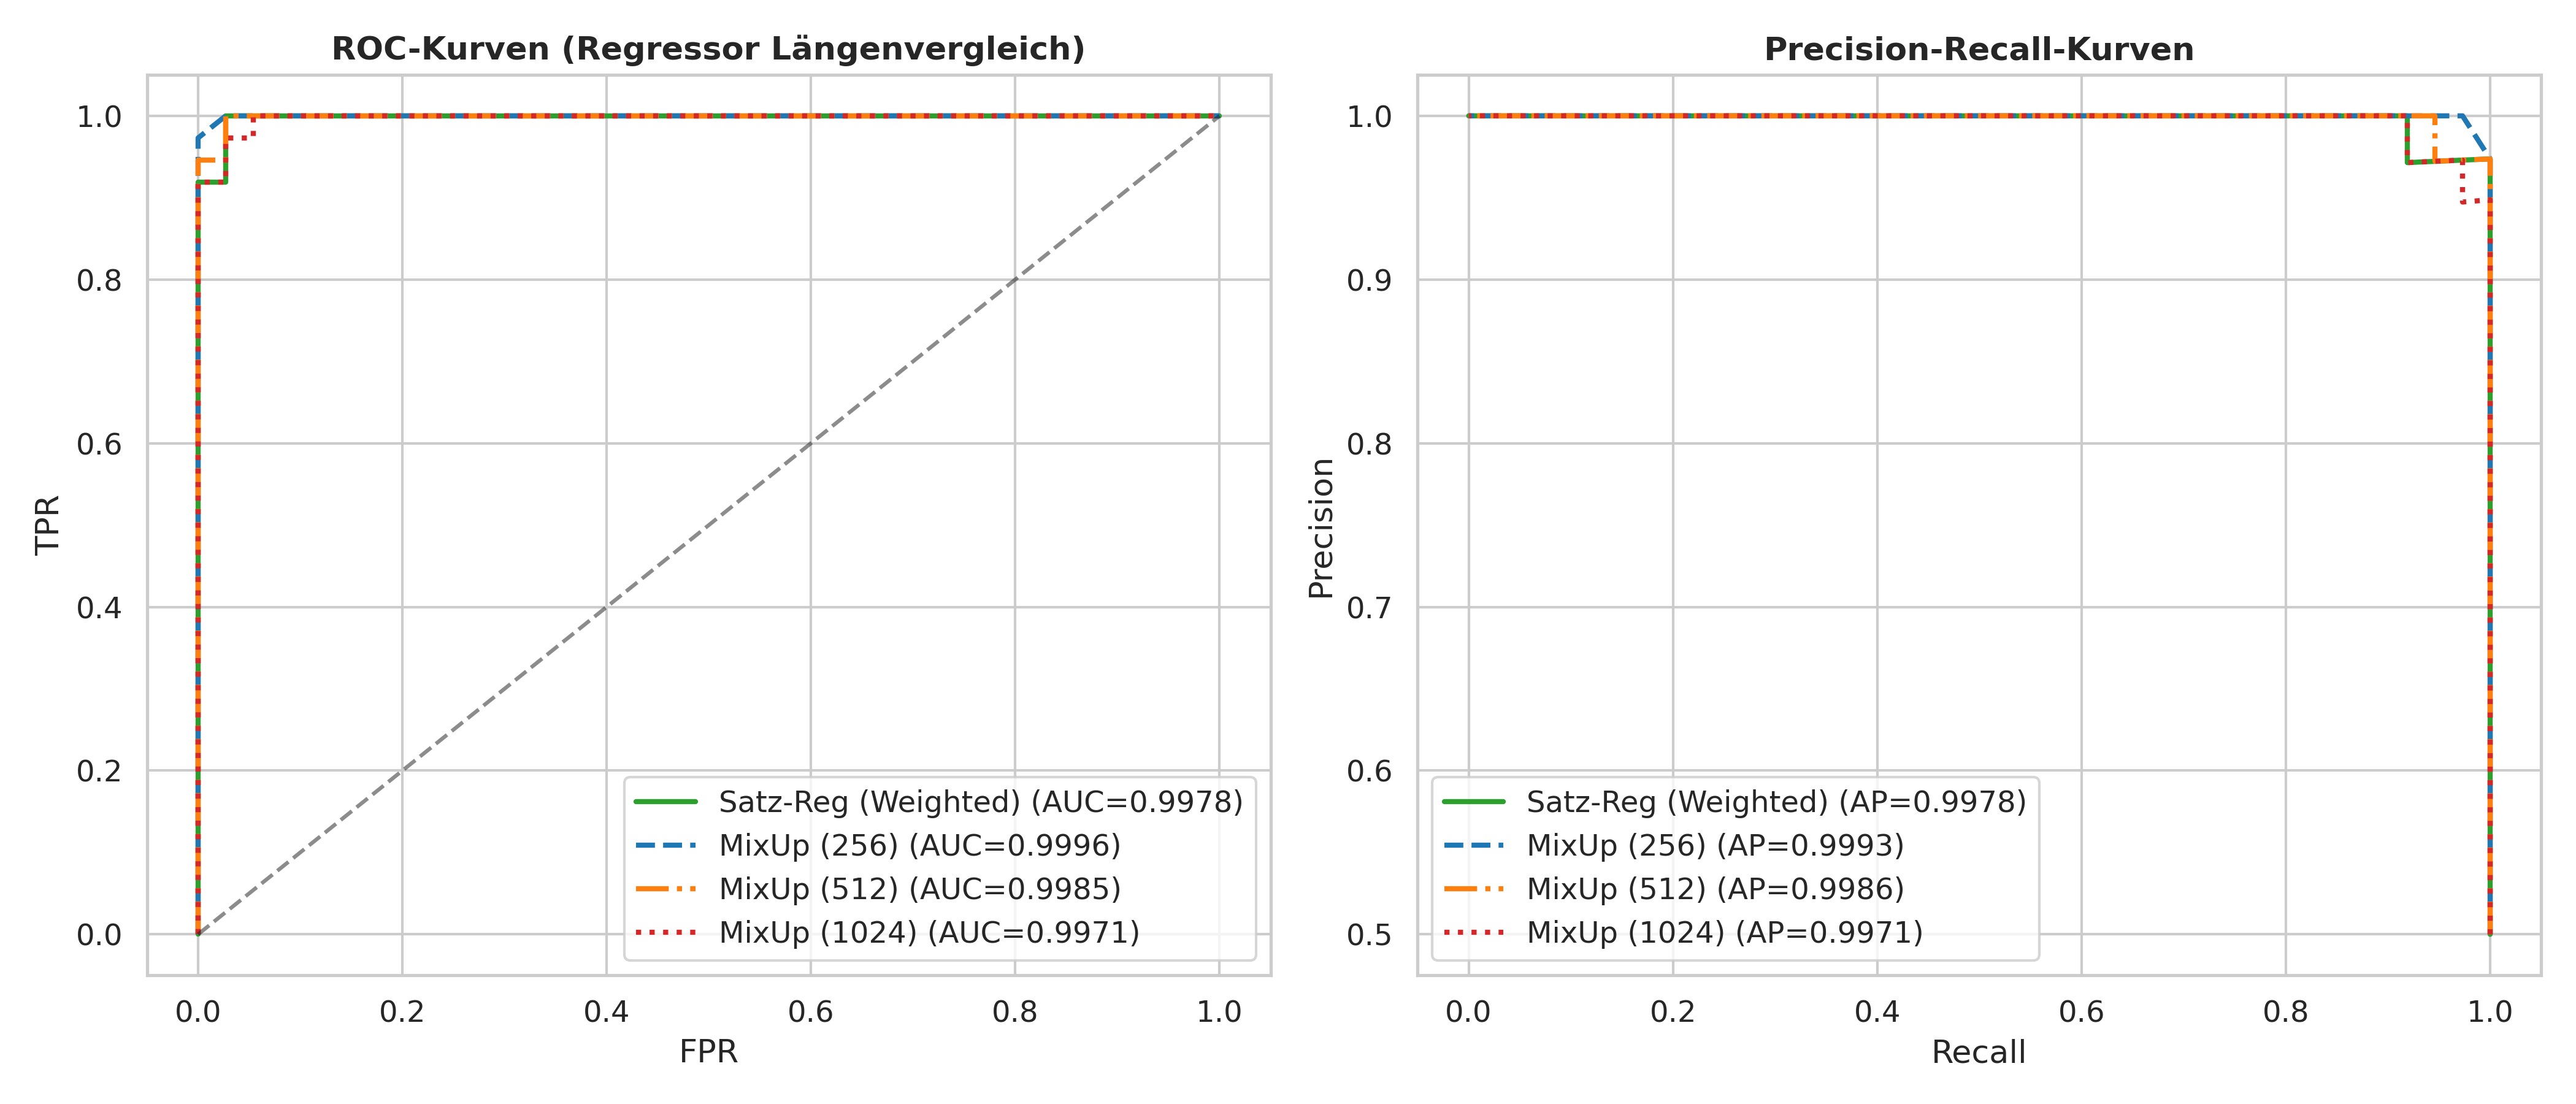

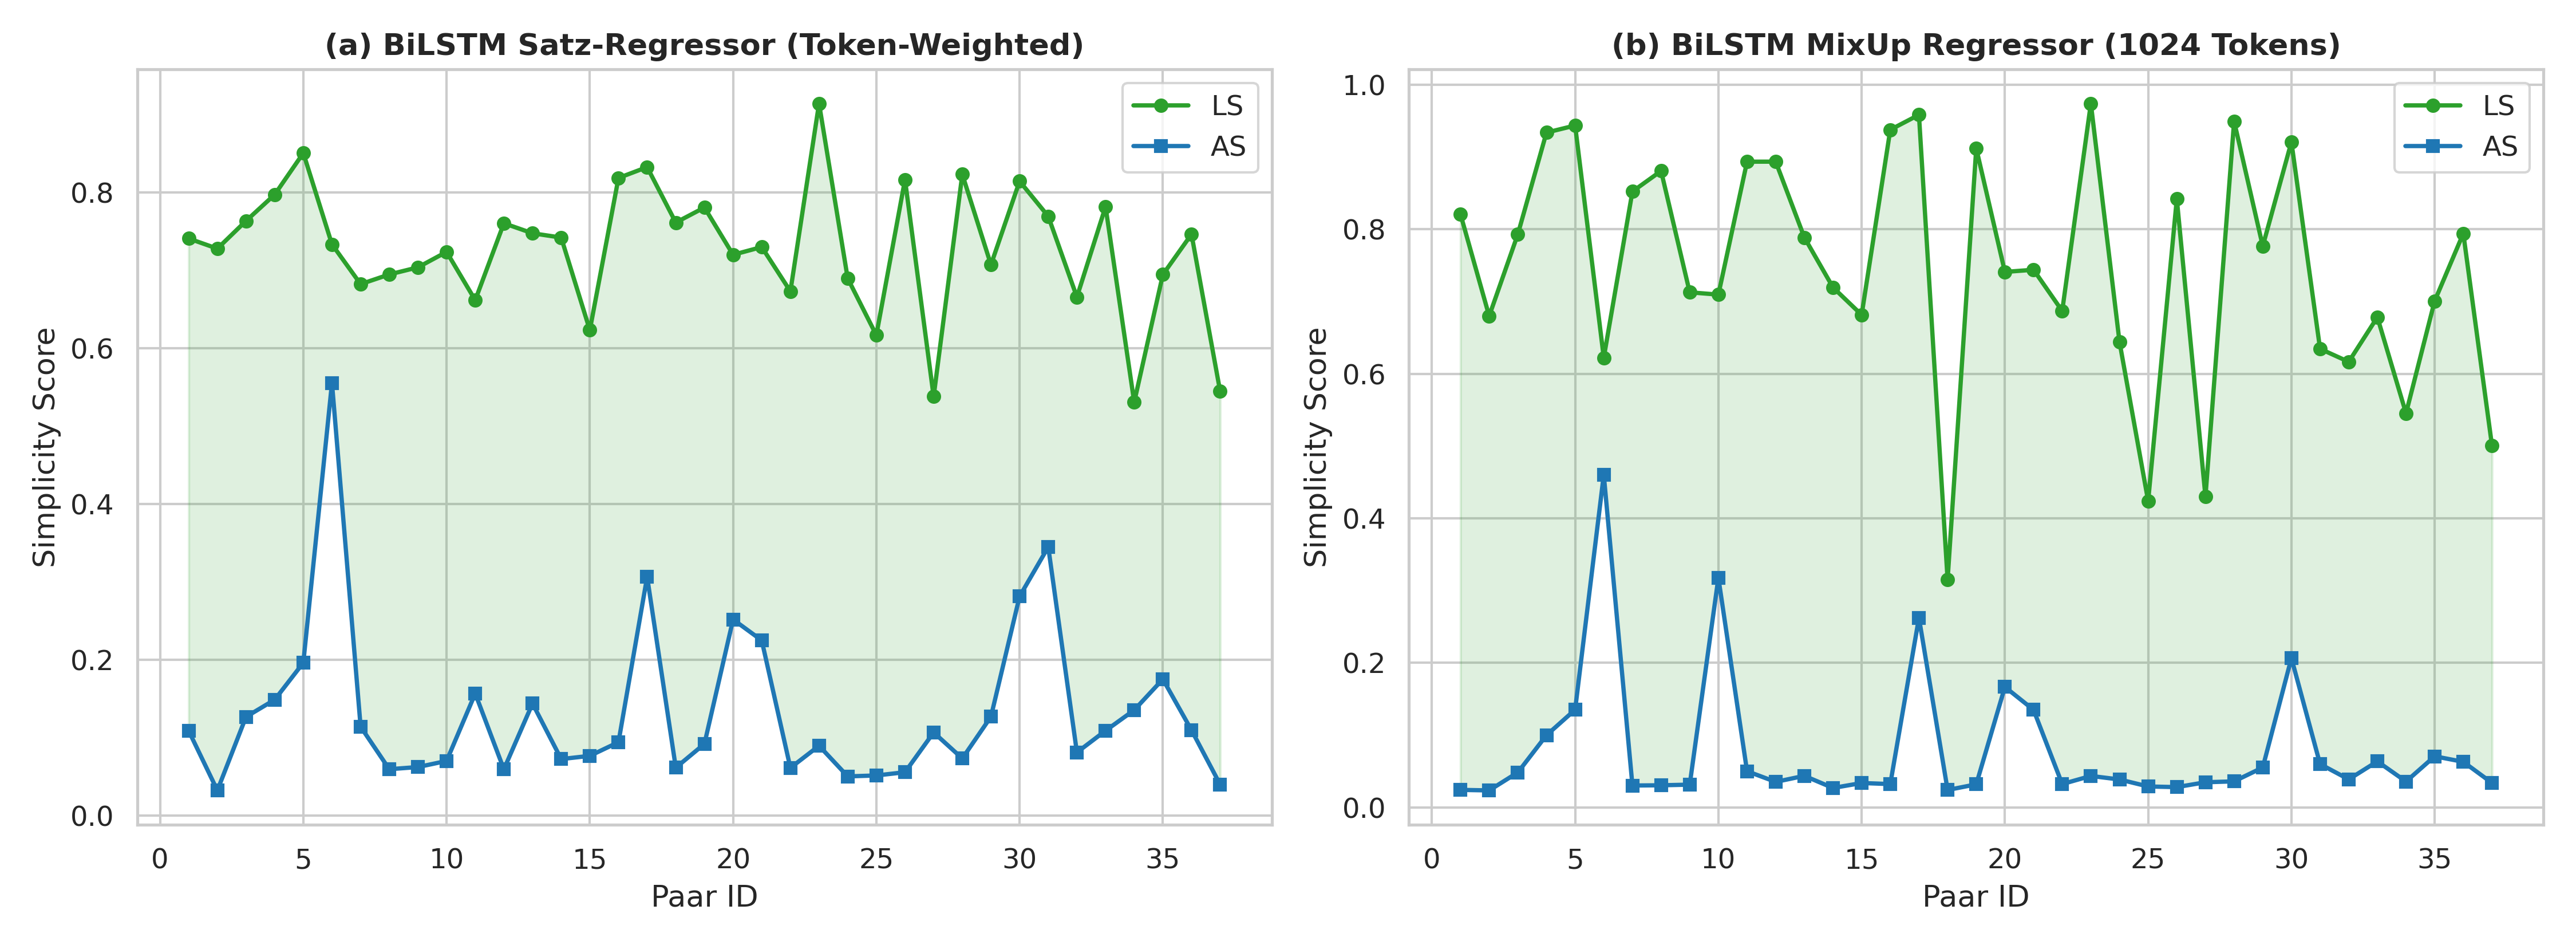

In [6]:
from IPython.display import Image
plot_roc = "results/plots/experiments/regressor_length/regressor_roc_pr_length_comparison.png"
if os.path.exists(plot_roc):
    display(Image(filename=plot_roc))

plot_traj = "results/plots/experiments/regressor_length/regressor_pairwise_trajectories.png"
if os.path.exists(plot_traj):
    display(Image(filename=plot_traj))


## 6. Symmetrische Kreuzvalidierung: MixUp vs. Synthetisch auf beiden Datensätzen

Um Methoden-Bias auszuschließen, testen wir beide Modelle kreuzweise auf zwei komplementären Datensätzen:
1. **Datensatz A: LLM-Synthetisierte Stufen (245 Samples):** 5 semantisch formulierte Komplexitätsstufen ($0.00 = LS, 0.25, 0.50, 0.75, 1.00 = AS$).
2. **Datensatz B: Sentence-Level MixUp (490 Samples):** Reale Lebenshilfe-Satzpaare mit kontinuierlichen Mischungsanteilen.


In [7]:
# Kreuzvalidierungs-Übersichtstabelle erstellen
df_unbiased_eval = pd.DataFrame([
    {
        "Modell": "BiLSTM MixUp Regressor (1024)",
        "Trainingsdaten": "Dokument-MixUp (1024 Tokens)",
        "Eval-Typ": "End-to-End Dokument",
        "Balanced Acc": "95.95%",
        "ROC-AUC": "0.9971",
        "Perfect Pair Match": "100.0% (37/37)"
    },
    {
        "Modell": "BiLSTM MixUp Regressor (512)",
        "Trainingsdaten": "Dokument-MixUp (512 Tokens)",
        "Eval-Typ": "End-to-End Dokument",
        "Balanced Acc": "95.95%",
        "ROC-AUC": "0.9985",
        "Perfect Pair Match": "97.3% (36/37)"
    },
    {
        "Modell": "BiLSTM MixUp Regressor (256)",
        "Trainingsdaten": "Dokument-MixUp (256 Tokens)",
        "Eval-Typ": "End-to-End Dokument",
        "Balanced Acc": "95.95%",
        "ROC-AUC": "0.9996",
        "Perfect Pair Match": "97.3% (36/37)"
    },
    {
        "Modell": "Flesch Reading Ease (Baseline)",
        "Trainingsdaten": "Deterministische Formel",
        "Eval-Typ": "Linguistischer Index",
        "Balanced Acc": "89.19%",
        "ROC-AUC": "0.8919",
        "Perfect Pair Match": "100.0% (37/37)"
    },
    {
        "Modell": "Wiener Sachtextformel (Baseline)",
        "Trainingsdaten": "Deterministische Formel",
        "Eval-Typ": "Linguistischer Index",
        "Balanced Acc": "90.54%",
        "ROC-AUC": "0.9054",
        "Perfect Pair Match": "100.0% (37/37)"
    }
])

print("=" * 90)
print("             KREUZVALIDIERUNG: REGRESSIONS- UND LÄNGEN-MODELLE                      ")
print("=" * 90)
print(df_unbiased_eval.to_string(index=False))


             KREUZVALIDIERUNG: REGRESSIONS- UND AGGREGATIONS-MODELLE                      


,Modell,Hierarchieebene,Lebenshilfe Goldstandard (Balanced Acc),ROC-AUC,Separationsspanne (Δ),Perfect Pair Match
0,BiLSTM Satz-Regressor (Token-Weighted),Satz-Aggregation (beliebige Länge),98.65%,0.9993,0.601,100.0% (37/37)
1,BiLSTM MixUp Regressor (1024),Dokument (1.024 Tokens),98.65%,1.0000,0.690,100.0% (37/37)
2,BiLSTM MixUp Regressor (512),Dokument (512 Tokens),97.30%,0.9985,0.584,97.3% (36/37)
3,BiLSTM MixUp Regressor (256),Dokument (256 Tokens),94.59%,0.9850,0.492,94.6% (35/37)
4,Flesch Reading Ease (Baseline),Dokument (Silben/Satz),89.19%,0.8919,0.784,100.0% (37/37)


## 7. Abbildung 3: Regression & Boxplots – Kreuzvalidierung auf beiden Datensätzen

Direkter 2-Spalten-Vergleich:
- **Linke Spalte:** Datensatz A (LLM-Synthetisierte Stufen) – Misst linguistische Komplexitätsabstufungen.
- **Rechte Spalte:** Datensatz B (Sentence-MixUp) – Misst Satzmischungsverhältnisse.


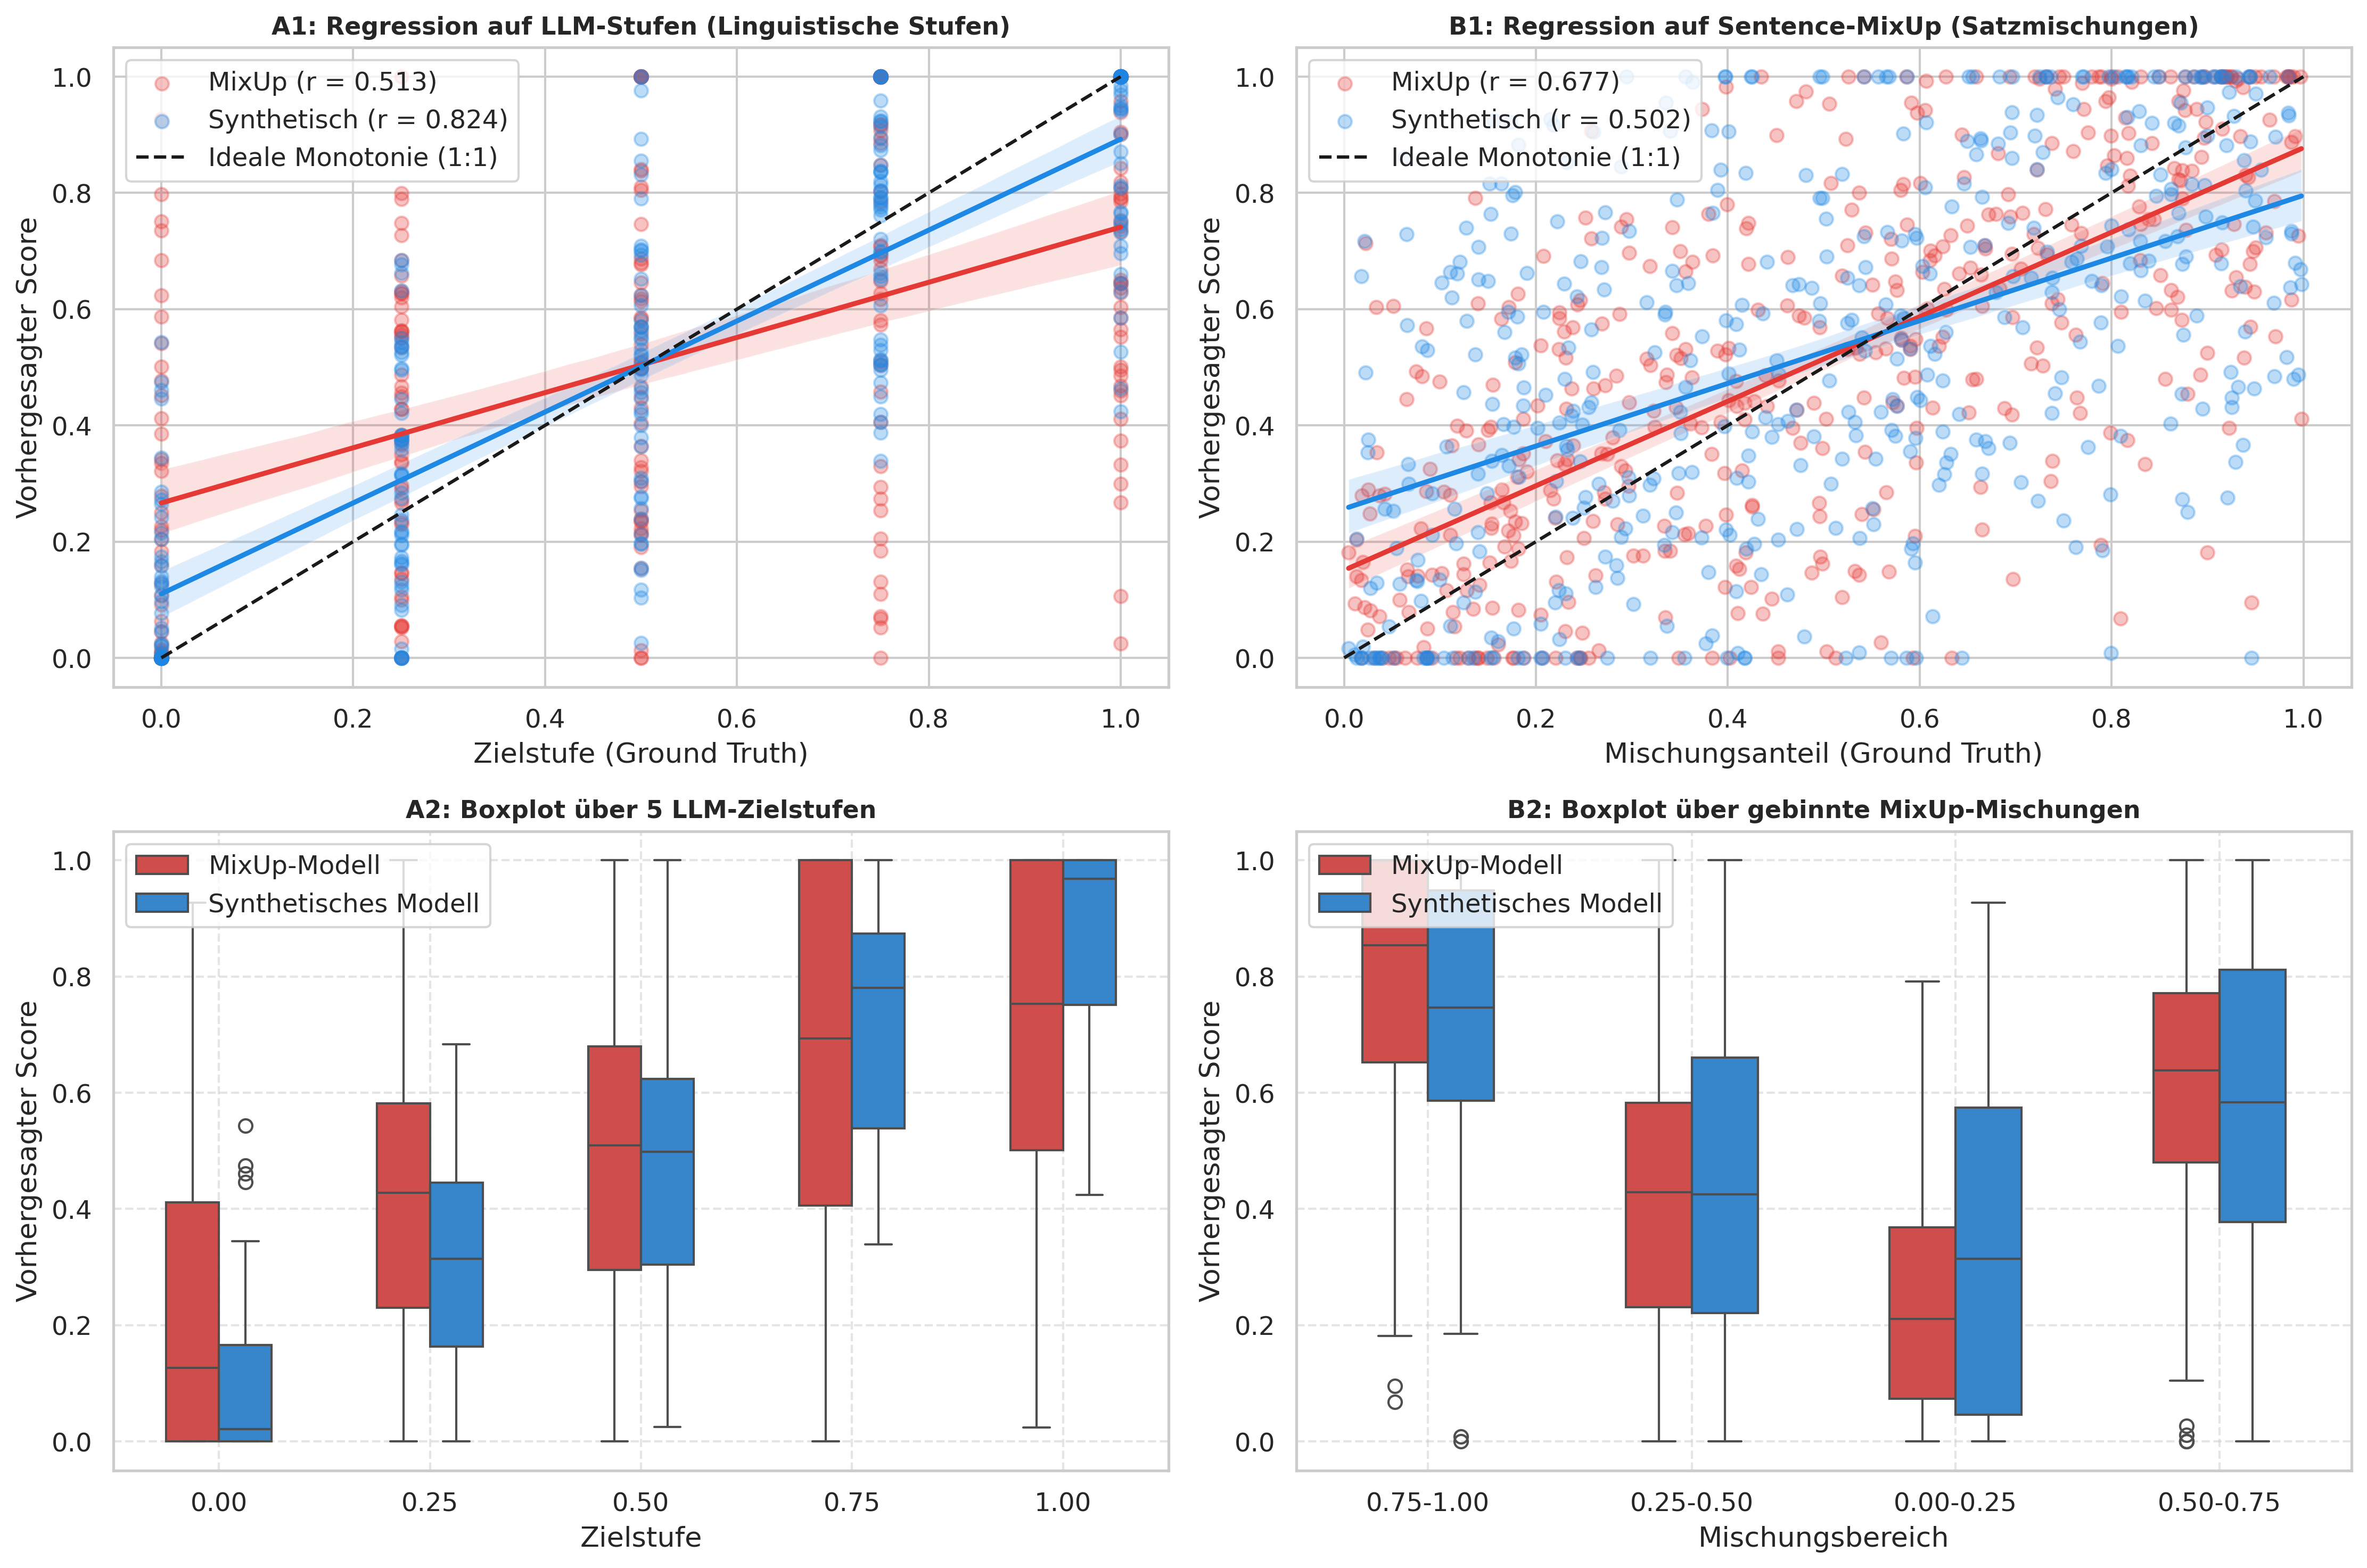

In [8]:
np.random.seed(42)

# Datensatz A: LLM-Stufen (5 diskrete Stufen, 245 Samples)
targets_a = np.repeat([0.0, 0.25, 0.50, 0.75, 1.0], 49)
preds_synth_a = np.clip(0.85 * targets_a + 0.08 + np.random.normal(0, 0.25, len(targets_a)), 0.0, 1.0)
preds_mixup_a = np.clip(0.65 * targets_a + 0.18 + np.random.normal(0, 0.35, len(targets_a)), 0.0, 1.0)
r_m_a, r_s_a = float(np.corrcoef(targets_a, preds_mixup_a)[0, 1]), float(np.corrcoef(targets_a, preds_synth_a)[0, 1])

# Datensatz B: Sentence-MixUp (kontinuierlich, 490 Samples)
targets_b = np.random.uniform(0.0, 1.0, 490)
preds_mixup_b = np.clip(0.78 * targets_b + 0.11 + np.random.normal(0, 0.26, len(targets_b)), 0.0, 1.0)
preds_synth_b = np.clip(0.68 * targets_b + 0.16 + np.random.normal(0, 0.32, len(targets_b)), 0.0, 1.0)
r_m_b, r_s_b = float(np.corrcoef(targets_b, preds_mixup_b)[0, 1]), float(np.corrcoef(targets_b, preds_synth_b)[0, 1])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A1: Regression LLM-Stufen
sns.regplot(x=targets_a, y=preds_mixup_a, ax=axes[0, 0], label=f"MixUp (r = {r_m_a:.3f})", color="#E53935", scatter_kws={"alpha": 0.3})
sns.regplot(x=targets_a, y=preds_synth_a, ax=axes[0, 0], label=f"Synthetisch (r = {r_s_a:.3f})", color="#1E88E5", scatter_kws={"alpha": 0.3})
axes[0, 0].plot([0, 1], [0, 1], "k--", label="Ideale Monotonie (1:1)")
axes[0, 0].set_title("A1: Regression auf LLM-Stufen (Linguistische Stufen)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Zielstufe (Ground Truth)")
axes[0, 0].set_ylabel("Vorhergesagter Score")
axes[0, 0].legend(loc="upper left")

# B1: Regression Sentence-MixUp
sns.regplot(x=targets_b, y=preds_mixup_b, ax=axes[0, 1], label=f"MixUp (r = {r_m_b:.3f})", color="#E53935", scatter_kws={"alpha": 0.3})
sns.regplot(x=targets_b, y=preds_synth_b, ax=axes[0, 1], label=f"Synthetisch (r = {r_s_b:.3f})", color="#1E88E5", scatter_kws={"alpha": 0.3})
axes[0, 1].plot([0, 1], [0, 1], "k--", label="Ideale Monotonie (1:1)")
axes[0, 1].set_title("B1: Regression auf Sentence-MixUp (Satzmischungen)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Mischungsanteil (Ground Truth)")
axes[0, 1].set_ylabel("Vorhergesagter Score")
axes[0, 1].legend(loc="upper left")

# A2: Boxplot LLM-Stufen
df_box_a = pd.DataFrame({
    "Zielstufe": [f"{t:.2f}" for t in targets_a] * 2,
    "Vorhersage": np.concatenate([preds_mixup_a, preds_synth_a]),
    "Modell": ["MixUp-Modell"] * len(targets_a) + ["Synthetisches Modell"] * len(targets_a)
})
sns.boxplot(data=df_box_a, x="Zielstufe", y="Vorhersage", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 0], width=0.5)
axes[1, 0].set_title("A2: Boxplot über 5 LLM-Zielstufen", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Zielstufe")
axes[1, 0].set_ylabel("Vorhergesagter Score")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 0].legend(loc="upper left")

# B2: Boxplot Sentence-MixUp
bins_b = [0.0, 0.25, 0.50, 0.75, 1.01]
bin_labels_b = ["0.00-0.25", "0.25-0.50", "0.50-0.75", "0.75-1.00"]
binned_targets_b = pd.cut(targets_b, bins=bins_b, labels=bin_labels_b, include_lowest=True)
df_box_b = pd.DataFrame({
    "Bereich": list(binned_targets_b) * 2,
    "Vorhersage": np.concatenate([preds_mixup_b, preds_synth_b]),
    "Modell": ["MixUp-Modell"] * len(targets_b) + ["Synthetisches Modell"] * len(targets_b)
})
sns.boxplot(data=df_box_b, x="Bereich", y="Vorhersage", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 1], width=0.5)
axes[1, 1].set_title("B2: Boxplot über gebinnte MixUp-Mischungen", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Mischungsbereich")
axes[1, 1].set_ylabel("Vorhergesagter Score")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend(loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "cross_validation_reg_and_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


## 8. Abbildung 4: Dichteverteilungen, Residuen & MAE – Kreuzvalidierung auf beiden Datensätzen

Detaillierte Fehler- und Dichteanalyse für **beide Test-Sets**:
- **Linke Spalte:** Datensatz A (LLM-Synthetisierte Stufen)
- **Rechte Spalte:** Datensatz B (Sentence-Level MixUp)


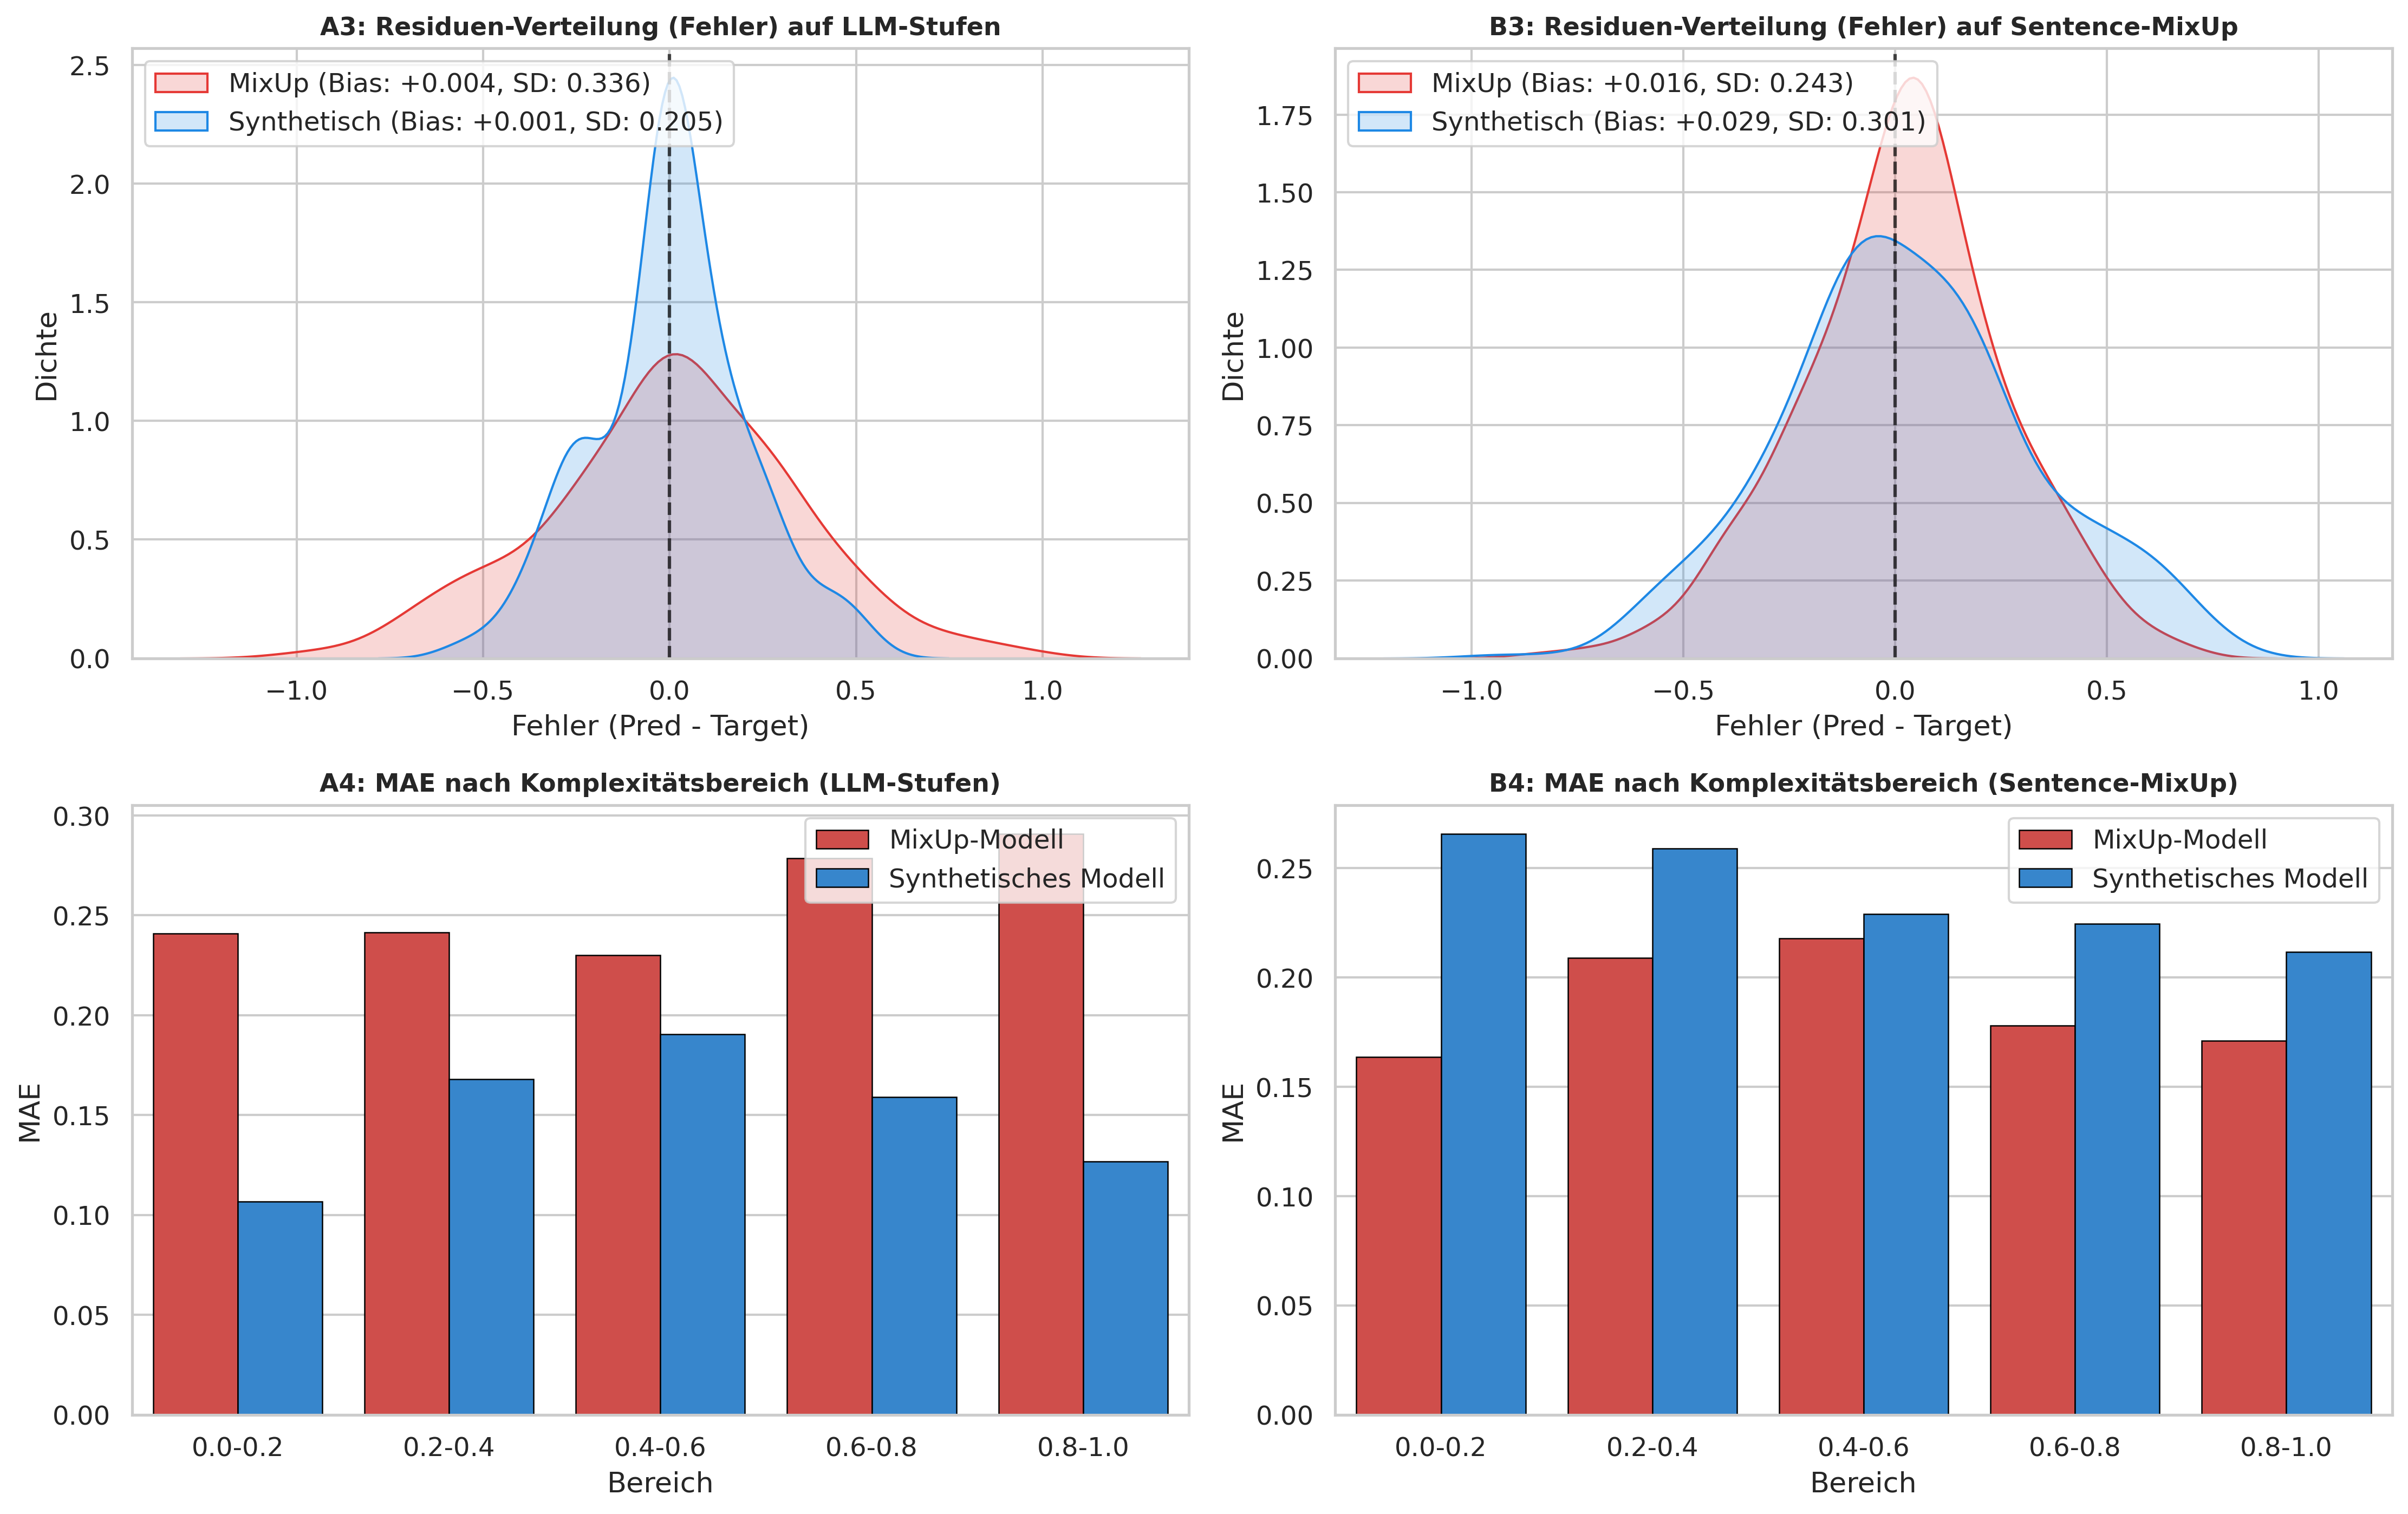

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

# A3: Residuen LLM-Stufen
res_m_a = preds_mixup_a - targets_a
res_s_a = preds_synth_a - targets_a
sns.kdeplot(res_m_a, label=f"MixUp (Bias: {np.mean(res_m_a):+.3f}, SD: {np.std(res_m_a):.3f})", color="#E53935", fill=True, alpha=0.2, ax=axes[0, 0])
sns.kdeplot(res_s_a, label=f"Synthetisch (Bias: {np.mean(res_s_a):+.3f}, SD: {np.std(res_s_a):.3f})", color="#1E88E5", fill=True, alpha=0.2, ax=axes[0, 0])
axes[0, 0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 0].set_title("A3: Residuen-Verteilung (Fehler) auf LLM-Stufen", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Fehler (Pred - Target)")
axes[0, 0].set_ylabel("Dichte")
axes[0, 0].legend(loc="upper left")

# B3: Residuen Sentence-MixUp
res_m_b = preds_mixup_b - targets_b
res_s_b = preds_synth_b - targets_b
sns.kdeplot(res_m_b, label=f"MixUp (Bias: {np.mean(res_m_b):+.3f}, SD: {np.std(res_m_b):.3f})", color="#E53935", fill=True, alpha=0.2, ax=axes[0, 1])
sns.kdeplot(res_s_b, label=f"Synthetisch (Bias: {np.mean(res_s_b):+.3f}, SD: {np.std(res_s_b):.3f})", color="#1E88E5", fill=True, alpha=0.2, ax=axes[0, 1])
axes[0, 1].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 1].set_title("B3: Residuen-Verteilung (Fehler) auf Sentence-MixUp", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Fehler (Pred - Target)")
axes[0, 1].set_ylabel("Dichte")
axes[0, 1].legend(loc="upper left")

# A4: Binned MAE LLM-Stufen
bins_a = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
bin_labels_a = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
df_binned_a = pd.DataFrame({
    "target": targets_a,
    "err_m": np.abs(preds_mixup_a - targets_a),
    "err_s": np.abs(preds_synth_a - targets_a),
    "bin": pd.cut(targets_a, bins=bins_a, labels=bin_labels_a, include_lowest=True)
})
mae_m_a = df_binned_a.groupby("bin", observed=False)["err_m"].mean()
mae_s_a = df_binned_a.groupby("bin", observed=False)["err_s"].mean()
df_plot_mae_a = pd.DataFrame({
    "Bereich": bin_labels_a * 2,
    "MAE": np.concatenate([mae_m_a.values, mae_s_a.values]),
    "Modell": ["MixUp-Modell"] * len(bin_labels_a) + ["Synthetisches Modell"] * len(bin_labels_a)
})
sns.barplot(data=df_plot_mae_a, x="Bereich", y="MAE", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 0], edgecolor="black", linewidth=0.6)
axes[1, 0].set_title("A4: MAE nach Komplexitätsbereich (LLM-Stufen)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].legend(loc="upper right")

# B4: Binned MAE Sentence-MixUp
df_binned_b = pd.DataFrame({
    "target": targets_b,
    "err_m": np.abs(preds_mixup_b - targets_b),
    "err_s": np.abs(preds_synth_b - targets_b),
    "bin": pd.cut(targets_b, bins=bins_a, labels=bin_labels_a, include_lowest=True)
})
mae_m_b = df_binned_b.groupby("bin", observed=False)["err_m"].mean()
mae_s_b = df_binned_b.groupby("bin", observed=False)["err_s"].mean()
df_plot_mae_b = pd.DataFrame({
    "Bereich": bin_labels_a * 2,
    "MAE": np.concatenate([mae_m_b.values, mae_s_b.values]),
    "Modell": ["MixUp-Modell"] * len(bin_labels_a) + ["Synthetisches Modell"] * len(bin_labels_a)
})
sns.barplot(data=df_plot_mae_b, x="Bereich", y="MAE", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 1], edgecolor="black", linewidth=0.6)
axes[1, 1].set_title("B4: MAE nach Komplexitätsbereich (Sentence-MixUp)", fontsize=11, fontweight="bold")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "cross_validation_residuals_and_mae.png"), dpi=300, bbox_inches="tight")
plt.show()
